Not included in the thesis! Calculating message variability in coarse context for all datasets: how many unique messages were used, divided by the total amount of messages in coarse context. Calculated separately for interactions from the last training epoch and test interactions.


 Plot at the end.

In [1]:
from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import error_analysis
from collections import Counter
from utils.analysis_from_interaction import *
import itertools
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('default')
import random
from seaborn.algorithms import bootstrap
import pickle
from utils.analysis_from_interaction import *
from egg.core.language_analysis import Disent
from language_analysis_local import TopographicSimilarityConceptLevel, encode_target_concepts_for_topsim
import os
import numpy as np

C:\Users\metel\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\metel\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# (potentially) useful functions copied from qualitative_utils.py from zero-shot repository by Kristina Kobrock
# https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/qualitative_utils.py

def objects_to_concepts(sender_input):
    """reconstruct concepts from objects in interaction"""
    n_targets = int(sender_input.shape[1]/2)
    # get target objects and fixed vectors to re-construct concepts
    target_objects = sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values[i])
    # concepts are defined by a list of target objects (here one sampled target object) and a fixed vector
    (objects, fixed) = retrieve_concepts_sampling(target_objects, all_targets=True)
    concepts = list(zip(objects, fixed))
    return concepts

# modified to trim the messages (delete the first 0 and everything that comes after)
# using trim_tensor from analysis_from_interaction.py
def retrieve_messages(interaction, is_gumbel=True):
    """retrieve messages from interaction"""
    if is_gumbel:
        messages = interaction.message.argmax(dim=-1)
        messages = [trim_tensor(message) for message in messages]
        messages = [msg.tolist() for msg in messages]
    else:
        messages = interaction.message.argmax(dim=2)
        messages = [trim_tensor(message) for message in messages]
        messages = [msg.tolist() for msg in messages]
    return messages


def count_symbols(messages):
    """counts symbols in messages"""
    all_symbols = [symbol for message in messages for symbol in message]
    symbol_counts = Counter(all_symbols)
    return symbol_counts

def get_unique_message_set(messages):
    """returns unique messages as a set ready for set operations"""
    return set(tuple(message) for message in messages)

def get_unique_concept_set(concepts):
    """returns unique concepts"""
    concept_tuples = []
    for objects, fixed in concepts:
        tuple_objects = []
        for object in objects:
            tuple_objects.append(tuple(object))
        tuple_objects = tuple(tuple_objects)
        tuple_concept = (tuple_objects, tuple(fixed))
        concept_tuples.append(tuple_concept)
    tuple(concept_tuples)
    unique_concepts = set(concept_tuples)
    return unique_concepts

In [3]:
# for Split datasets
def get_variety_split_by_attribute(interaction_test, att, n_values, retrieve_context_condition, retrieve_messages, k_hot_to_attributes, retrieve_concepts_sampling):
    n_targets = int(interaction_test.sender_input.shape[1] / 2)
    target_objects = interaction_test.sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values)
    objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
    distractor_objects = interaction_test.sender_input[:, n_targets:]
    distractor_objects = k_hot_to_attributes(distractor_objects, n_values)
    context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
    messages = retrieve_messages(interaction_test, is_gumbel=False)
    mask = [(c == 0) and (f[att] == 1) for c, f in zip(context_conds, fixed)]
    filtered_messages = [msg for msg, keep in zip(messages, mask) if keep]
    n_total = sum(mask)
    unique_messages = set(tuple(m) for m in filtered_messages)
    variety = len(unique_messages) / n_total if n_total > 0 else 0
    unique_symbols = set(s for m in filtered_messages for s in m)
    return {
        "variety": variety,
        "n_unique_messages": len(unique_messages),
        "n_total_messages": n_total,
        "n_unique_symbols": len(unique_symbols),
        "unique_messages": unique_messages,
        "unique_symbols": unique_symbols,
    }

#for No-split datasets
def get_variety_shared_context(interaction_train, att, n_values, retrieve_context_condition, retrieve_messages, k_hot_to_attributes, retrieve_concepts_sampling):
    n_targets = int(interaction_train.sender_input.shape[1] / 2)
    target_objects = interaction_train.sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values)
    objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
    distractor_objects = interaction_train.sender_input[:, n_targets:]
    distractor_objects = k_hot_to_attributes(distractor_objects, n_values)
    context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
    messages = retrieve_messages(interaction_train)
    mask = [(c == 0) and (f[att] == 1) for c, f in zip(context_conds, fixed)]
    filtered_messages = [msg for msg, keep in zip(messages, mask) if keep]
    n_total = sum(mask)
    unique_messages = set(tuple(m) for m in filtered_messages)
    variety = len(unique_messages) / n_total if n_total > 0 else 0
    unique_symbols = set(s for m in filtered_messages for s in m)
    return {
        "variety": variety,
        "n_unique_messages": len(unique_messages),
        "n_total_messages": n_total,
        "n_unique_symbols": len(unique_symbols),
        "unique_messages": unique_messages,
        "unique_symbols": unique_symbols,
        "attribute": att,
    }

def avg_shared_variety_over_atts(interaction, n_values_i, n_atts_i):
    vals = []
    for att in range(n_atts_i):
        res = get_variety_shared_context(
            interaction, att, n_values_i,
            retrieve_context_condition, retrieve_messages,
            k_hot_to_attributes, retrieve_concepts_sampling
        )
        vals.append(float(res["variety"]))
    return float(np.mean(vals)) if vals else float('nan')

def shared_variety_per_run(interaction, n_values_i, n_atts_i):
    """Return a list of scores, one per attribute, for this run."""
    scores = []
    for att in range(n_atts_i):
        res = get_variety_shared_context(
            interaction, att, n_values_i,
            retrieve_context_condition, retrieve_messages,
            k_hot_to_attributes, retrieve_concepts_sampling
        )
        scores.append(float(res["variety"]))
    return scores

In [11]:
# for Split datasets
def new_get_variety_split_by_attribute(interaction_test, att, n_values, retrieve_context_condition, retrieve_messages, k_hot_to_attributes, retrieve_concepts_sampling):
    n_targets = int(interaction_test.sender_input.shape[1] / 2)
    target_objects = interaction_test.sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values)
    objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
    distractor_objects = interaction_test.sender_input[:, n_targets:]
    distractor_objects = k_hot_to_attributes(distractor_objects, n_values)
    context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
    messages = retrieve_messages(interaction_test, is_gumbel=False)
    mask = [c == 0 for c in context_conds]
    filtered_messages = [msg for msg, keep in zip(messages, mask) if keep]
    n_total = sum(mask)
    unique_messages = set(tuple(m) for m in filtered_messages)
    variety = len(unique_messages) / n_total if n_total > 0 else 0
    unique_symbols = set(s for m in filtered_messages for s in m)
    return {
        "variety": variety,
        "n_unique_messages": len(unique_messages),
        "n_total_messages": n_total,
        "n_unique_symbols": len(unique_symbols),
        "unique_messages": unique_messages,
        "unique_symbols": unique_symbols,
    }

#for No-split datasets
def get_variety_shared_context(interaction_train, att, n_values, retrieve_context_condition, retrieve_messages, k_hot_to_attributes, retrieve_concepts_sampling):
    n_targets = int(interaction_train.sender_input.shape[1] / 2)
    target_objects = interaction_train.sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values)
    objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
    distractor_objects = interaction_train.sender_input[:, n_targets:]
    distractor_objects = k_hot_to_attributes(distractor_objects, n_values)
    context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
    messages = retrieve_messages(interaction_train)
    mask = [(c == 0) and (f[att] == 1) for c, f in zip(context_conds, fixed)]
    filtered_messages = [msg for msg, keep in zip(messages, mask) if keep]
    n_total = sum(mask)
    unique_messages = set(tuple(m) for m in filtered_messages)
    variety = len(unique_messages) / n_total if n_total > 0 else 0
    unique_symbols = set(s for m in filtered_messages for s in m)
    return {
        "variety": variety,
        "n_unique_messages": len(unique_messages),
        "n_total_messages": n_total,
        "n_unique_symbols": len(unique_symbols),
        "unique_messages": unique_messages,
        "unique_symbols": unique_symbols,
        "attribute": att,
    }

def avg_shared_variety_over_atts(interaction, n_values_i, n_atts_i):
    vals = []
    for att in range(n_atts_i):
        res = get_variety_shared_context(
            interaction, att, n_values_i,
            retrieve_context_condition, retrieve_messages,
            k_hot_to_attributes, retrieve_concepts_sampling
        )
        vals.append(float(res["variety"]))
    return float(np.mean(vals)) if vals else float('nan')

def shared_variety_per_run(interaction, n_values_i, n_atts_i):
    """Return a list of scores, one per attribute, for this run."""
    scores = []
    for att in range(n_atts_i):
        res = get_variety_shared_context(
            interaction, att, n_values_i,
            retrieve_context_condition, retrieve_messages,
            k_hot_to_attributes, retrieve_concepts_sampling
        )
        scores.append(float(res["variety"]))
    return scores

D(3,3) Split, No length cost, Vocab size 13,

 5 runs

HDA - highly discriminative attribute

HDA Indices in each run: 1, 0, 2, 1, 0

In [13]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [9]:
att_per_run = [1, 0, 2, 1, 0] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")



[(3,3)] Train variety mean ± std over runs: 0.210 ± 0.075
[(3,3)] Test variety mean ± std over runs: 0.072 ± 0.012


In [14]:
att_per_run = [1, 0, 2, 1, 0] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = new_get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = new_get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")



[(3,3)] Train variety mean ± std over runs: 0.226 ± 0.058
[(3,3)] Test variety mean ± std over runs: 0.067 ± 0.009


D(3,3) No split (shared_context), No Length cost, vocab 13

5 runs

In [15]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [16]:
for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_train,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context train variety over runs: {mean_d:.3f} ± {std_d:.3f}")

for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_test,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context test variety over runs: {mean_d:.3f} ± {std_d:.3f}")

[(3,3)] Shared-context train variety over runs: 0.107 ± 0.021
[(3,3)] Shared-context test variety over runs: 0.116 ± 0.026


In [17]:
att_per_run = [1, 0, 2, 1, 0] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = new_get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = new_get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")



[(3,3)] Train variety mean ± std over runs: 0.093 ± 0.019
[(3,3)] Test variety mean ± std over runs: 0.108 ± 0.022


D(3,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 0, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [23]:
att_per_run = [0, 0] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

[(3,4)] Train variety mean ± std over runs: 0.194 ± 0.070
[(3,4)] Test variety mean ± std over runs: 0.077 ± 0.028


D(3,4) No split (shared_context), No Length cost, vocab 16

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [45]:
for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_train,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context train variety over runs: {mean_d:.3f} ± {std_d:.3f}")

for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_test,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context test variety over runs: {mean_d:.3f} ± {std_d:.3f}")

[(3,4)] Shared-context train variety over runs: 0.084 ± 0.030
[(3,4)] Shared-context test variety over runs: 0.115 ± 0.011


D(4,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 3, 2

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [25]:
att_per_run = [3, 2] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

[(4,4)] Train variety mean ± std over runs: 0.308 ± 0.063
[(4,4)] Test variety mean ± std over runs: 0.089 ± 0.011


D(4,4) No split (shared_context), No Length cost vocab 16

2 runs

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [47]:
for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_train,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context train variety over runs: {mean_d:.3f} ± {std_d:.3f}")

for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_test,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context test variety over runs: {mean_d:.3f} ± {std_d:.3f}")

[(4,4)] Shared-context train variety over runs: 0.182 ± 0.003
[(4,4)] Shared-context test variety over runs: 0.136 ± 0.046


In [51]:
for i, d in enumerate(datasets):
    per_run_avgs_train = []
    print(f"\n=== {d} | TRAIN (shared-context) ===")
    for run in range(n_runs):
        epoch = n_epochs_all_data[i][run]
        path_to_run = f"{paths[i]}/{setting}/{run}/"
        path_to_interaction_train = f"{path_to_run}interactions/train/epoch_{epoch}/interaction_gpu0"
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)

        # Per-attribute scores for this run
        att_scores = shared_variety_per_run(interaction_train, n_values[i], n_attributes[i])
        avg_run = float(np.mean(att_scores)) if len(att_scores) > 0 else float('nan')
        per_run_avgs_train.append(avg_run)

        # Print detailed per-run info
        pretty_scores = ", ".join(f"{s:.3f}" for s in att_scores)
        print(f"Run {run}: att scores [{pretty_scores}] | avg={avg_run:.3f}")

    # Summary over runs
    mean_d = float(np.mean(per_run_avgs_train)) if per_run_avgs_train else float('nan')
    std_d  = float(np.std (per_run_avgs_train, ddof=1)) if len(per_run_avgs_train) > 1 else float('nan')
    print(f"[{d}] TRAIN shared-context variety over runs: {mean_d:.3f} ± {std_d:.3f}")

# =========================
# TEST
# =========================
for i, d in enumerate(datasets):
    per_run_avgs_test = []
    print(f"\n=== {d} | TEST (shared-context) ===")
    for run in range(n_runs):
        path_to_run = f"{paths[i]}/{setting}/{run}/"
        path_to_interaction_test = f"{path_to_run}interactions/{split_test_ds}/epoch_0/interaction_gpu0"
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

        # Per-attribute scores for this run
        att_scores = shared_variety_per_run(interaction_test, n_values[i], n_attributes[i])
        avg_run = float(np.mean(att_scores)) if len(att_scores) > 0 else float('nan')
        per_run_avgs_test.append(avg_run)

        # Print detailed per-run info
        pretty_scores = ", ".join(f"{s:.3f}" for s in att_scores)
        print(f"Run {run}: att scores [{pretty_scores}] | avg={avg_run:.3f}")

    # Summary over runs
    mean_d = float(np.mean(per_run_avgs_test)) if per_run_avgs_test else float('nan')
    std_d  = float(np.std (per_run_avgs_test, ddof=1)) if len(per_run_avgs_test) > 1 else float('nan')
    print(f"[{d}] TEST shared-context variety over runs: {mean_d:.3f} ± {std_d:.3f}")


=== (4,4) | TRAIN (shared-context) ===
Run 0: att scores [0.185, 0.173, 0.191, 0.186] | avg=0.184
Run 1: att scores [0.177, 0.179, 0.178, 0.186] | avg=0.180
[(4,4)] TRAIN shared-context variety over runs: 0.182 ± 0.003

=== (4,4) | TEST (shared-context) ===
Run 0: att scores [0.176, 0.162, 0.161, 0.175] | avg=0.168
Run 1: att scores [0.109, 0.098, 0.101, 0.108] | avg=0.104
[(4,4)] TEST shared-context variety over runs: 0.136 ± 0.046


D(3,8) Split, No Length cost, vocab 28

2 runs

HDA indices in each run: 2, 1

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [27]:
att_per_run = [2, 1] # indices of highly discriminative attributes per run
all_varieties_train = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_train,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_train.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Train variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

all_varieties_test = [] 
for i, d in enumerate(datasets):
    #print(d)
    varieties_this_dataset = []  # per-dataset accumulator
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        # Example usage for test set (split by attribute)
        att = att_per_run[run]  # attribute index you want to analyze
        result_split = get_variety_split_by_attribute(
            interaction_test,  # your loaded test interaction object
            att,
            n_values[i],  # number of values per attribute for this dataset
            retrieve_context_condition,
            retrieve_messages,
            k_hot_to_attributes,
            retrieve_concepts_sampling
        )
        #print(path_to_run)
        #print("Split by attribute results:")
        #for key, value in result_split.items():
        #    print(f"{key}: {value}")
        v = result_split["variety"]
        varieties_this_dataset.append(v)
        all_varieties_test.append(v)
    # per-dataset summary
    mean_d = float(np.mean(varieties_this_dataset)) if varieties_this_dataset else float('nan')
    std_d  = float(np.std (varieties_this_dataset, ddof=1)) if len(varieties_this_dataset) > 1 else float('nan')
    print(f"[{d}] Test variety mean ± std over runs: {mean_d:.3f} ± {std_d:.3f}")

[(3,8)] Train variety mean ± std over runs: 0.195 ± 0.008
[(3,8)] Test variety mean ± std over runs: 0.071 ± 0.007


D(3,8) No split (shared_context), No Length cost, vocab 28

2 runs

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [49]:
for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_train,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context train variety over runs: {mean_d:.3f} ± {std_d:.3f}")

for i, d in enumerate(datasets):
    #print(d)
    per_run_vals = []
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        v_run = avg_shared_variety_over_atts(
            interaction_test,
            n_values[i],       # e.g., 3
            n_attributes[i]    # e.g., 3 (so att=0,1,2)
        )
        per_run_vals.append(v_run)
    mean_d = float(np.mean(per_run_vals)) if per_run_vals else float('nan')
    std_d  = float(np.std (per_run_vals, ddof=1)) if len(per_run_vals) > 1 else float('nan')
    print(f"[{d}] Shared-context test variety over runs: {mean_d:.3f} ± {std_d:.3f}")

[(3,8)] Shared-context train variety over runs: 0.058 ± 0.015
[(3,8)] Shared-context test variety over runs: 0.059 ± 0.008


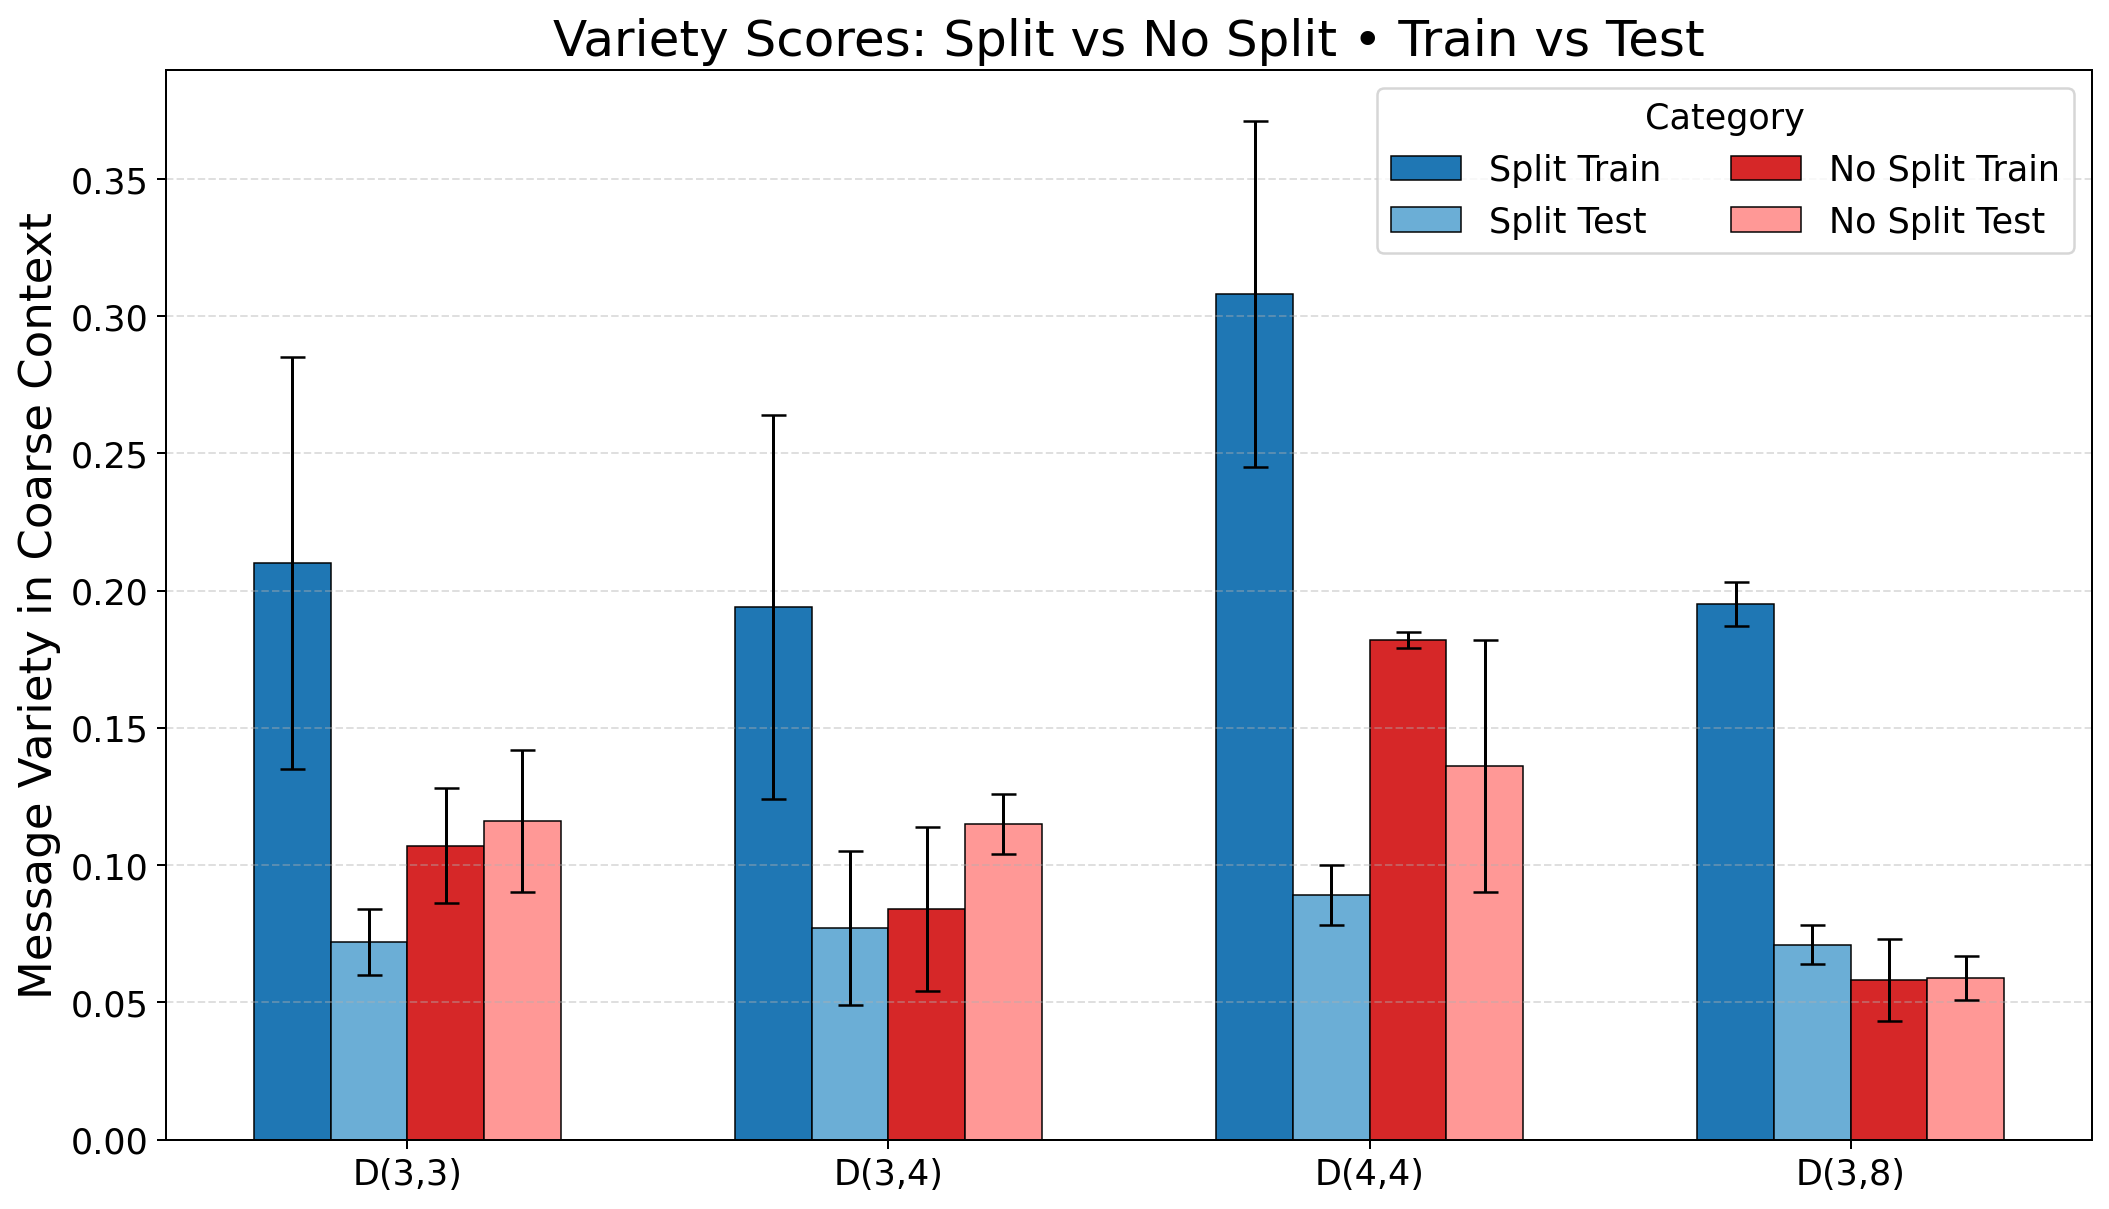

In [6]:
# plotting
import matplotlib.pyplot as plt
import numpy as np


data = {
    "D(3,3)": {
        "Split Train":    (0.210, 0.075),
        "Split Test":     (0.072, 0.012),
        "No Split Train": (0.107, 0.021),
        "No Split Test":  (0.116, 0.026),
    },
    "D(3,4)": {
        "Split Train":    (0.194, 0.070),
        "Split Test":     (0.077, 0.028),
        "No Split Train": (0.084, 0.030),
        "No Split Test":  (0.115, 0.011),
    },
    "D(4,4)": {
        "Split Train":    (0.308, 0.063),
        "Split Test":     (0.089, 0.011),
        "No Split Train": (0.182, 0.003),
        "No Split Test":  (0.136, 0.046),
    },
    "D(3,8)": {
        "Split Train":    (0.195, 0.008),
        "Split Test":     (0.071, 0.007),
        "No Split Train": (0.058, 0.015),
        "No Split Test":  (0.059, 0.008),
    },
}

# order of dataset groups and categories (bar order inside each group)
groups = ["D(3,3)", "D(3,4)", "D(4,4)", "D(3,8)"]
categories = ["Split Train", "Split Test", "No Split Train", "No Split Test"]


plt.rcParams.update({
    "font.size": 16,            # base font
    "axes.titlesize": 20,       # plot title
    "axes.labelsize": 18,       # axis labels
    "xtick.labelsize": 14,      # x tick labels
    "ytick.labelsize": 14,      # y tick labels
    "legend.fontsize": 14,      # legend text
    "legend.title_fontsize": 14 # legend title
})


color_map = {
    "Split Train":    "#1f77b4",  # deep blue
    "Split Test":     "#6baed6",  # lighter blue
    "No Split Train": "#d62728",  # deep red
    "No Split Test":  "#ff9896",  # lighter red
}


n_groups = len(groups)
n_series = len(categories)
bar_width = 0.22
group_spacing = 0.5  


x_base = np.arange(n_groups) * (n_series * bar_width + group_spacing)


fig = plt.figure(figsize=(12, 7), dpi=180)

for s, cat in enumerate(categories):
    x = x_base + s * bar_width
    means = [data[g][cat][0] for g in groups]
    stds  = [data[g][cat][1] for g in groups]
    plt.bar(
        x, means,
        width=bar_width,
        yerr=stds,
        capsize=5,
        ecolor="black",
        error_kw=dict(lw=1.2),
        label=cat,
        color=color_map[cat],
        edgecolor="black",
        linewidth=0.6,
    )


xticks = x_base + (n_series - 1) * bar_width / 2
plt.xticks(xticks, groups)

plt.ylabel("Message Variety in Coarse Context")
plt.title("Variety Scores: Split vs No Split • Train vs Test")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Category", ncol=2, frameon=True, loc="upper right")
plt.tight_layout()


plt.show()